#노드 구성
1.  retrive
2.  generate
3.  rewrite
4. 문서검증

In [1]:
!uv pip install langchain langchain_openai langchain_chroma langgraph

Audited 4 packages in 42ms


In [2]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vectorstore = Chroma(       
    embedding_function=embedding_function,
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection"
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


In [3]:
from typing_extensions import List,TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    query: str
    answer: str
    context: List[Document]
    
    
graph_builder = StateGraph(AgentState)
    

In [4]:
def retrieve(state: AgentState) :
    query = state["query"]
    docs = retriever.invoke(query)
    return {"context": docs}

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o", temperature=0)

# 프롬프트가 여러개 필요함!
1. generate
2. rewrite
3. 문서관련성

In [6]:
from langsmith import Client
from urllib3 import response

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state:AgentState) :
    context = state["context"]
    query = state["query"]
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({"context": context, "question": query})
    return {"answer": response}


In [7]:
# 문서 관련성 측정 노드 (상태에 _next를 넣어 다음 노드로 연결)

from langsmith import Client
from typing import Literal

client = Client()
doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal["generate", "rewrite"]:
    query = state["query"]
    context = state["context"]
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({"documents": context, "question": query})
    # 응답에서 Score 추출 (AIMessage면 .content, dict면 ["Score"])
    if response['Score'] == 1:
        return 'generate'
    else:
        return 'rewrite'


In [8]:
query = "연봉 5천만원 직장인의 소득세는?"

In [9]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(
    f"""
    주어진 질문에 대한 답변을 찾아보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    사전 : {dictionary}
    질문 : {{query}}
    """
)

def rewrite(state:AgentState) :
    query = state["query"]
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    
    response = rewrite_chain.invoke({"query": query})
    return {"query": response}

In [ ]:
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)
graph_builder.add_node("rewrite", rewrite)


In [11]:
from langgraph.graph import START, END
graph_builder.add_edge(START, "retrieve")
graph_builder.add_conditional_edges("retrieve", check_doc_relevance)
graph_builder.add_edge("rewrite", "retrieve")
graph_builder.add_edge("generate", END)

In [12]:
graph = graph_builder.compile()

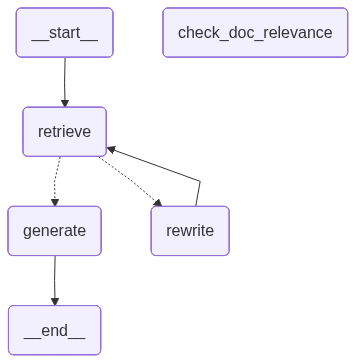

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
initial_state = {"query": query}
graph.invoke(initial_state)

{'query': '질문을 사전에 따라 변경하면 다음과 같습니다:\n\n"연봉 5천만원 거주자의 소득세는?"',
 'answer': AIMessage(content='연봉 5천만원 거주자의 소득세는 624만원입니다. 이는 5천만원을 초과하는 금액에 대해 24%의 세율이 적용되기 때문입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 1683, 'total_tokens': 1727, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-D3G9gKKxTz0rwxAZkamDenL5OAA9v', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c0884-f269-7e53-bce0-dbbed393fbd3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1683, 'output_tokens': 44, 'total_tokens': 1727, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 're